In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/72.0 MB 2.4 MB/s eta 0:00:30
    --------------------------------------- 1.6/72.0 MB 2.8 MB/s eta 0:00:26
   - -------------------------------------- 2.4/72.0 MB 3.1 MB/s eta 0:00:23
   - -------------------------------------- 3.4/72.0 MB 3.5 MB/s eta 0:00:20
   -- ------------------------------------- 4.5/72.0 MB 3.8 MB/s eta 0:00:18
   --- ------------------------------------ 5.8/72.0 MB 4.1 MB/s eta 0:00:17
   --- ------------------------------------ 7.1/72.0 MB 4.4 MB/s eta 0:00:15
   ---- ----------------------------------- 8.9/72.0 MB 4.9 MB/s eta 0:00:13
   ----- ---------------------------------- 10.2/72.0 MB 5.1 MB/s eta 0:00:13
   ------ ----------------

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error as mae
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('train.csv')
display(df.head())
display(df.tail())

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


,date,store,item,sales
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62
912999,2017-12-31,10,50,82


In [6]:
df.shape

(913000, 4)

In [7]:
df.info

<bound method DataFrame.info of               date  store  item  sales
0       2013-01-01      1     1     13
1       2013-01-02      1     1     11
2       2013-01-03      1     1     14
3       2013-01-04      1     1     13
4       2013-01-05      1     1     10
...            ...    ...   ...    ...
912995  2017-12-27     10    50     63
912996  2017-12-28     10    50     59
912997  2017-12-29     10    50     74
912998  2017-12-30     10    50     62
912999  2017-12-31     10    50     82

[913000 rows x 4 columns]>

In [31]:
df.describe()

,date,store,item,sales,year,month,day,weekend,holidays
count,913000,913000.000000,913000.000000,913000.000000,913000.000000,913000.000000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287,2015.000548,6.523549,15.727820,0.285871,0.043264
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000,2013.000000,1.000000,1.000000,0.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000,2014.000000,4.000000,8.000000,0.000000,0.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000,2015.000000,7.000000,16.000000,0.000000,0.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000,2016.000000,10.000000,23.000000,1.000000,0.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000,2017.000000,12.000000,31.000000,1.000000,1.000000
std,NaN,2.872283,14.430878,28.801144,1.414021,3.448535,8.799329,0.451828,0.203451


In [40]:
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day']   = df['date'].dt.day
df.head()

,date,store,item,sales,year,month,day,weekend,holidays
0,2013-01-01,1,1,13,2013,1,1,0,0
1,2013-01-02,1,1,11,2013,1,2,0,0
2,2013-01-03,1,1,14,2013,1,3,0,0
3,2013-01-04,1,1,13,2013,1,4,0,0
4,2013-01-05,1,1,10,2013,1,5,1,0


In [42]:
import pandas as pd

df['date'] = pd.to_datetime(df[['year','month','day']])
df['weekend'] = df['date'].dt.weekday.apply(lambda x: 1 if x > 4 else 0)

df[['year','month','day','weekend']].head()

,year,month,day,weekend
0,2013,1,1,0
1,2013,1,2,0
2,2013,1,3,0
3,2013,1,4,0
4,2013,1,5,1


In [43]:
import holidays

india_holidays = holidays.country_holidays('IN')

df['holidays'] = df['date'].apply(lambda x: 1 if x.date() in india_holidays else 0)

df[['date','holidays']].head()


,date,holidays
0,2013-01-01,0
1,2013-01-02,0
2,2013-01-03,0
3,2013-01-04,0
4,2013-01-05,0


In [44]:
df['m1'] = np.sin(df['month'] * (2 * np.pi / 12))
df['m2'] = np.cos(df['month'] * (2 * np.pi / 12))
df.head()

,date,store,item,sales,year,month,day,weekend,holidays,m1,m2
0,2013-01-01,1,1,13,2013,1,1,0,0,0.5,0.866025
1,2013-01-02,1,1,11,2013,1,2,0,0,0.5,0.866025
2,2013-01-03,1,1,14,2013,1,3,0,0,0.5,0.866025
3,2013-01-04,1,1,13,2013,1,4,0,0,0.5,0.866025
4,2013-01-05,1,1,10,2013,1,5,1,0,0.5,0.866025


In [48]:
from datetime import datetime

def which_day(year, month, day):
    return datetime(int(year), int(month), int(day)).weekday()

df['weekday'] = df.apply(lambda x: which_day(x['year'], x['month'], x['day']), axis=1)

df[['year','month','day','weekday']].head()


,year,month,day,weekday
0,2013,1,1,1
1,2013,1,2,2
2,2013,1,3,3
3,2013,1,4,4
4,2013,1,5,5


In [49]:
df.drop('date', axis=1, inplace=True)

In [50]:
df['store'].nunique(), df['item'].nunique()

(10, 50)

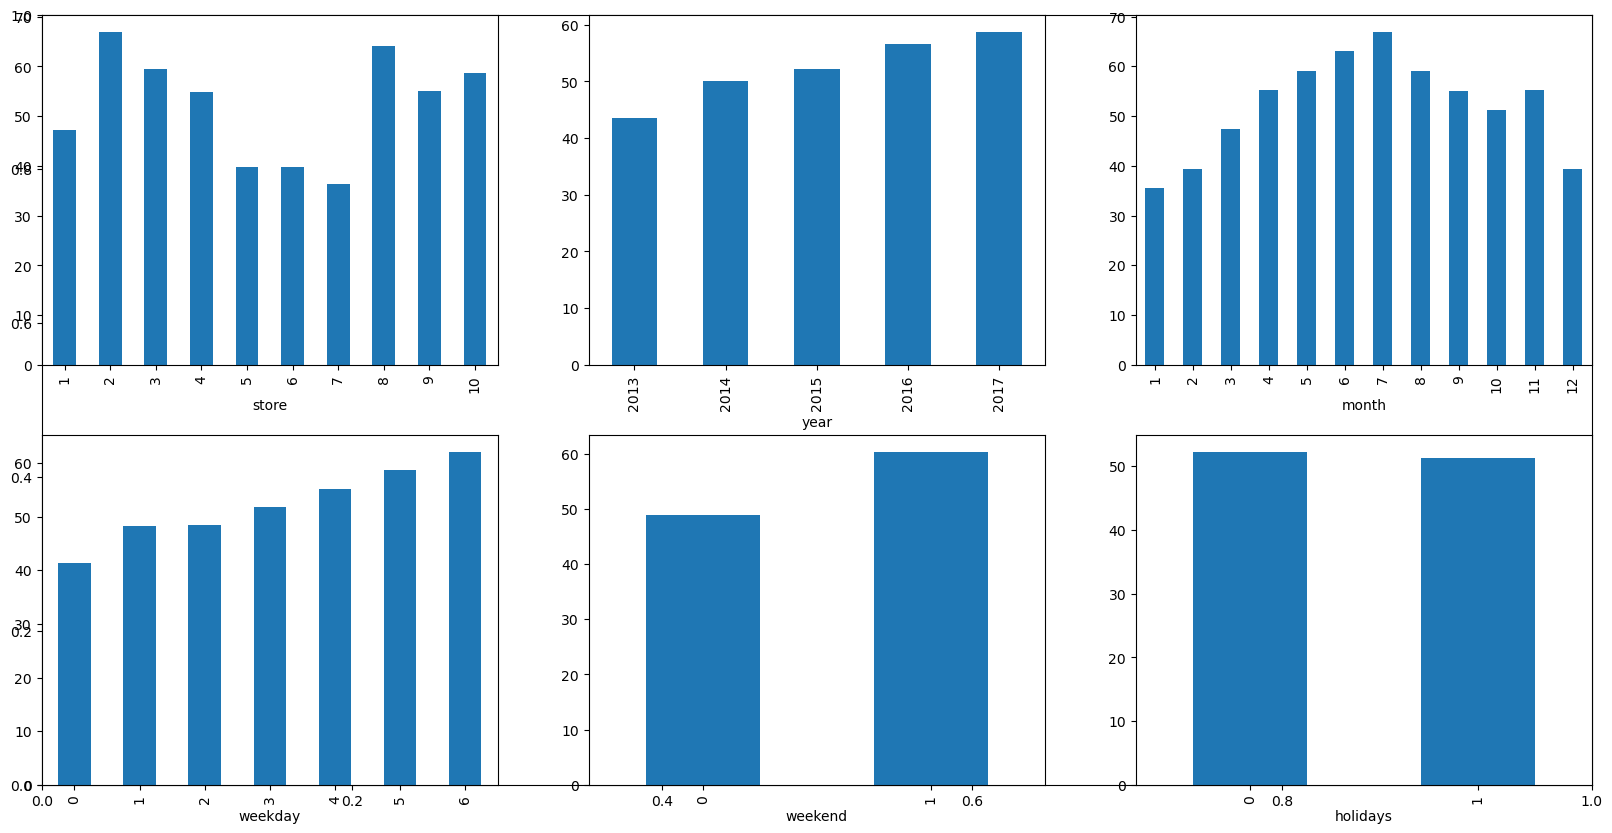

In [51]:
df['weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
features = ['store', 'year', 'month', 'weekday', 'weekend', 'holidays']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    df.groupby(col).mean()['sales'].plot.bar()
plt.show()

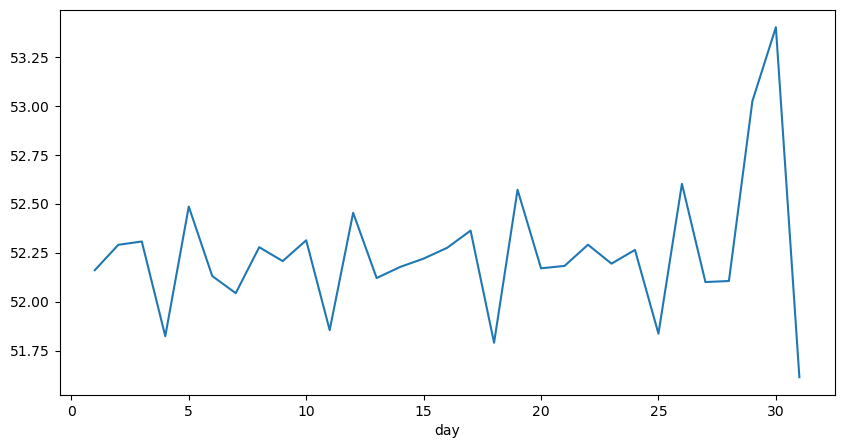

In [52]:
plt.figure(figsize=(10,5))
df.groupby('day').mean()['sales'].plot()
plt.show()

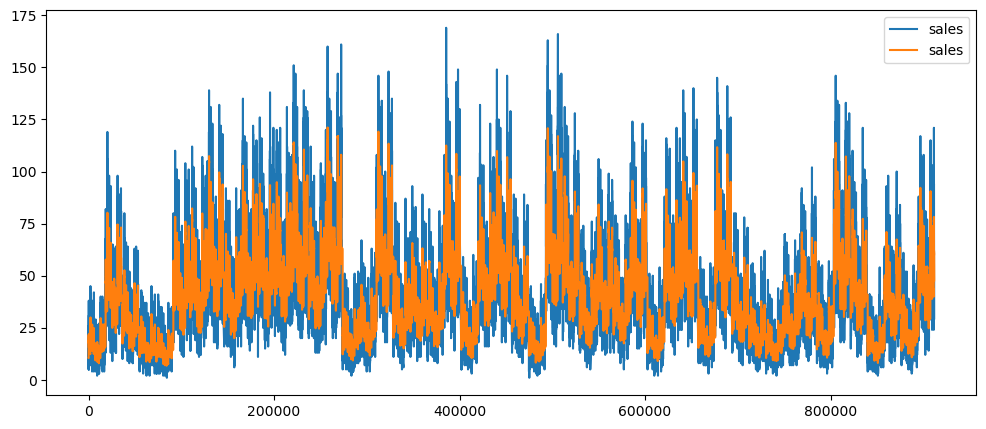

In [83]:
plt.figure(figsize=(12, 5))

window_size = 30
data = df[df['year']==2013]
windows = data['sales'].rolling(window_size)
sma = windows.mean()
sma = sma[window_size - 1:]

data['sales'].plot()
sma.plot()
plt.legend()
plt.show()

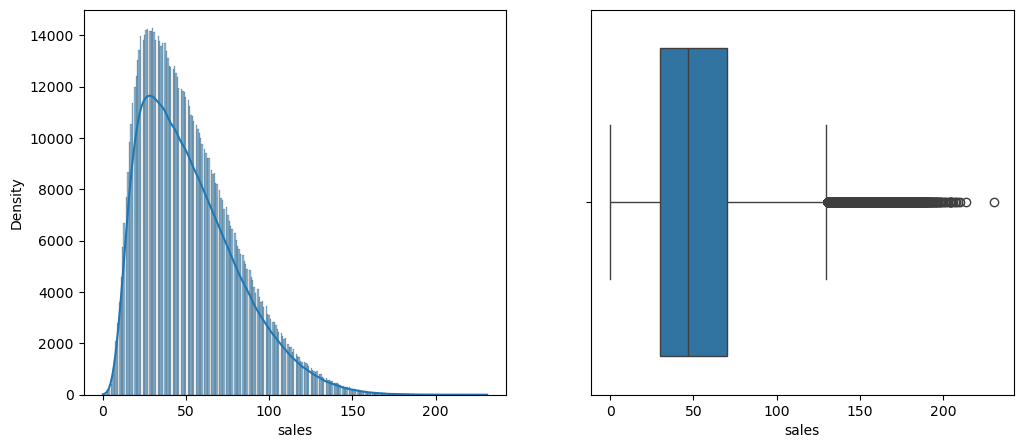

In [92]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sb.histplot(df['sales'], kde=True)
plt.xlabel("sales")
plt.ylabel("Density")

plt.subplot(1,2,2)
sb.boxplot(x=df['sales'])
plt.xlabel("sales")
plt.show()

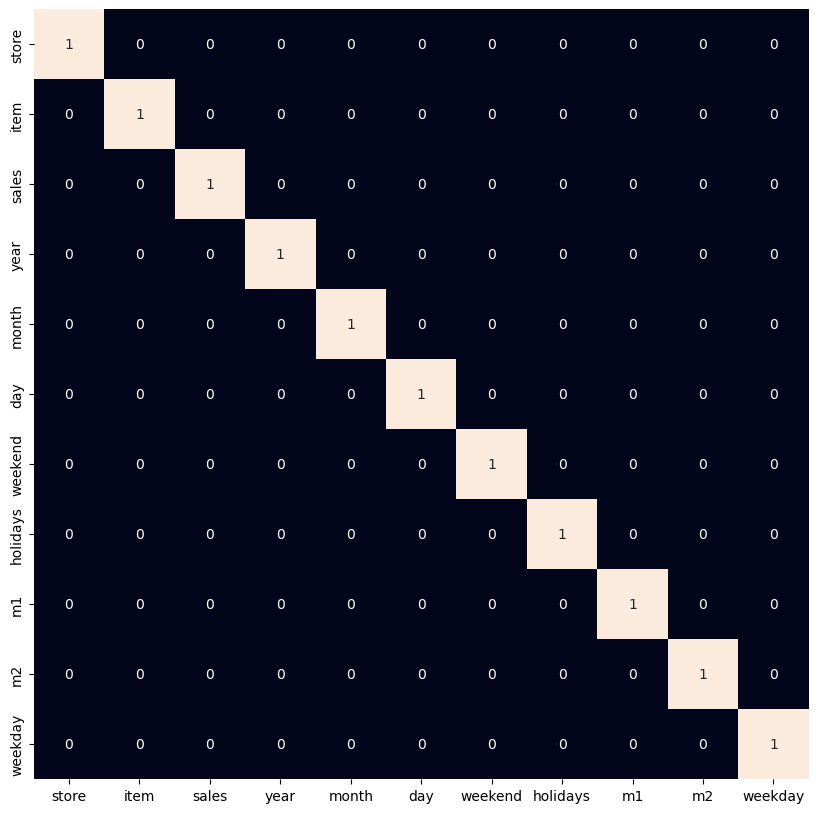

In [93]:
plt.figure(figsize=(10, 10))
sb.heatmap(df.corr() > 0.8,
           annot=True,
           cbar=False)
plt.show()

In [94]:
df = df[df['sales']<140]

In [95]:
features = df.drop(['sales', 'year'], axis=1)
target = df['sales'].values


X_train, X_val, Y_train, Y_val = train_test_split(features, target,
                                                  test_size = 0.05,
                                                  random_state=22)
X_train.shape, X_val.shape

((861170, 9), (45325, 9))

In [97]:
# Normalizing the features for stable and fast training.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [98]:
models = [LinearRegression(), XGBRegressor(), Lasso(), Ridge()]

for i in range(4):
    models[i].fit(X_train, Y_train)

    print(f'{models[i]} : ')

    train_preds = models[i].predict(X_train)
    print('Training Error : ', mae(Y_train, train_preds))

    val_preds = models[i].predict(X_val)
    print('Validation Error : ', mae(Y_val, val_preds))
    print()

LinearRegression() : 
Training Error :  20.903011639935794
Validation Error :  20.971878842602617

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) : 
Training Error :  6.9172892570495605
Validation Error :  6.9274091720581055

Lasso() : 
Training Error :  21.015028699769758
Validation Error :  21.